
# **WINE QUALITY PREDICTION**

**INTRODUCTION**

Wine quality evaluation is commonly influenced by human sensory judgment, which can be subjective and inconsistent. In this project, machine learning techniques are applied to estimate wine quality using physicochemical attributes. The objective is to develop a predictive model capable of classifying wine quality more objectively and efficiently, with a **quality rating ranging from 0 to 10**.

**DATASET**

The dataset is the Wine Quality Dataset, which consists of two primary parts:

1. **Training Data** : Contains samples of red and white wine along with their physicochemical attributes and quality labels.
2. **Testing Data** : Contains physicochemical attributes of wine samples without quality labels.

**STEPS**

This analysis combines **exploratory data analysis**, **preprocessing**, **visualization**, and **classification algorithms to compare model** performance on the wine quality dataset.




**DATA PREPARATION**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Load data
from google.colab import files
uploaded = files.upload()

train = pd.read_excel("data_training.xlsx")
test = pd.read_excel("data_testing.xlsx")

#Show 5 head data
print("\n~~~ TRAIN DATA ~~~")
display(train.head())
print("\n~~~ TRAIN DATA ~~~")
display(test.head())

print("Training Shape :", train.shape)
print("Testing Shape :", test.shape)


Saving data_testing.xlsx to data_testing (2).xlsx
Saving data_training.xlsx to data_training (2).xlsx

~~~ TRAIN DATA ~~~


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918



~~~ TRAIN DATA ~~~


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14,1.00100,3.25,0.74,11.900000,516


Training Shape : (857, 13)
Testing Shape : (286, 12)


**EXPLORATORY DATA ANALYSIS**

**1. Overview**

In [ ]:
print(train.info())
print(train.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB
None
       fixed acidity  volatile acidity  citric acid  residual sugar  \
co

In [ ]:
print(test.info())
print(test.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         286 non-null    float64
 1   volatile acidity      286 non-null    float64
 2   citric acid           286 non-null    float64
 3   residual sugar        286 non-null    float64
 4   chlorides             286 non-null    float64
 5   free sulfur dioxide   286 non-null    float64
 6   total sulfur dioxide  286 non-null    int64  
 7   density               286 non-null    float64
 8   pH                    286 non-null    float64
 9   sulphates             286 non-null    float64
 10  alcohol               286 non-null    float64
 11  Id                    286 non-null    int64  
dtypes: float64(10), int64(2)
memory usage: 26.9 KB
None
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count     286.000000        286.000000   286.000000  

**2. Missing Values**

In [ ]:
print("\n~~~ TRAIN DATA ~~~")
print("\nMissing Values:\n",train.isnull().sum())
print("\n~~~ TESTING DATA ~~~")
print("\nMissing Values:\n",test.isnull().sum())


~~~ TRAIN DATA ~~~

Missing Values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

~~~ TESTING DATA ~~~

Missing Values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


all variables have complete data (0 missing values). he dataset is ready for analysis without further imputation or data cleaning.

**3. Duplicate Data**

In [ ]:
train.duplicated().sum()

np.int64(0)

In [ ]:
test.duplicated().sum()

np.int64(0)

number of duplicates is 0

**4. Correlation Heatmap**

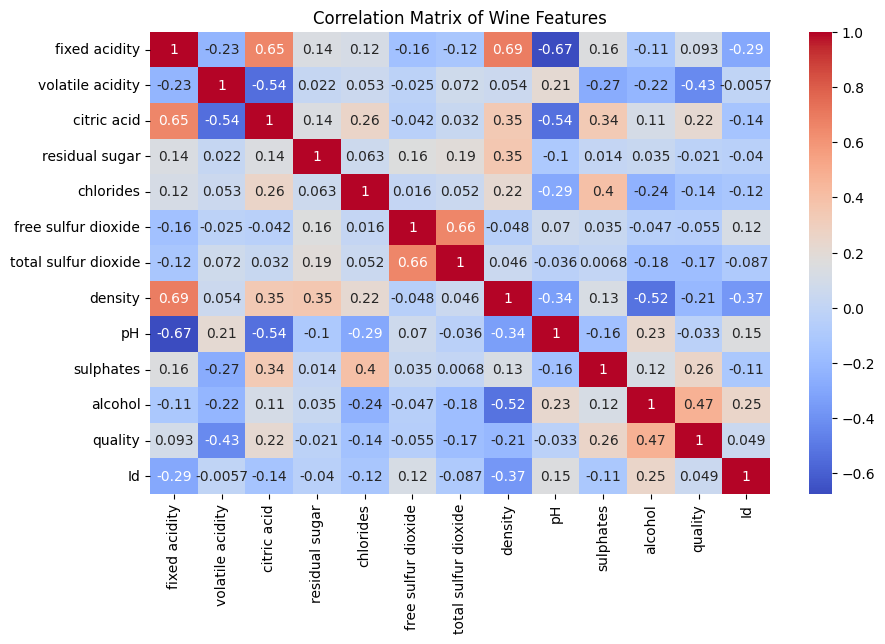

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(train.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Wine Features')
plt.show()

**5. Distribution Visualization**

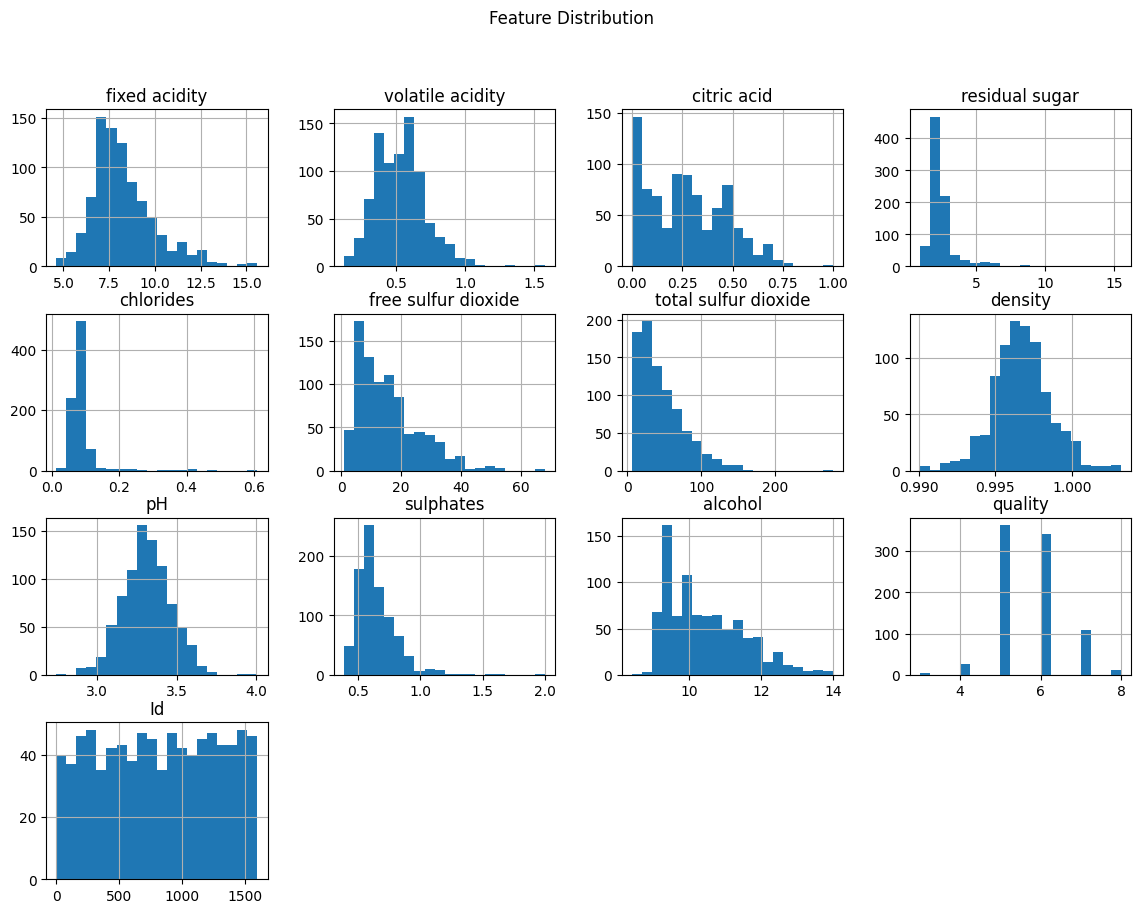

In [ ]:
train.hist(figsize=(14,10), bins=20)
plt.suptitle('Feature Distribution')
plt.show()

**PREPROCESSING**

the data preprocessing steps:

1.   Feature and Target Separation: The training data is divided into X (features, i.e., all columns except 'quality') and y (the target, which is the 'quality' column).
2.   ID Handling: The 'Id' column from the test dataset is saved as test_id and then removed from both the training features (X) and test features (X_test) because it is not a predictive feature.
3. Feature Scaling: Features are scaled using StandardScaler. The mean and standard deviation are calculated from the training features (X_scaled) and then used to scale the test features (X_test_scaled), ensuring all features have a mean of zero and a variance of one.




In [ ]:
# Separate features and targets
X = train.drop("quality", axis=1)
y = train["quality"]

# Save as ID test
test_id = test["Id"]

# Remove ID column from feature
X = X.drop("Id", axis=1)
X_test = test.drop("Id", axis=1)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

**SPLIT DATA TRAINING TEST**

splits the scaled feature data (X_scaled) and target (y) into training and validation sets. test_size=0.2 allocates 20% of the data for validation. random_state=42 ensures consistent splitting for reproducibility.

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

**MODEL TRAINING**

Initializes a RandomForestClassifier model, the model is trained using the feature data (X_train) and target

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

RandomForestClassifier(n_estimators=200, random_state=42) indicates that the RandomForestClassifier model has been successfully initialized and trained with the specified number of trees (n_estimators) and a given random state.

**EVALUATE THE MODEL**

evaluates the performance of the trained RandomForestClassifier model by making predictions (y_pred) on the validation dataset (X_val). It then calculates and displays the accuracy score (accuracy_score) to show the proportion of correct predictions, and presents a classification_report for a more detailed analysis of the model's precision, recall, and F1-score for each target class.



In [ ]:
y_pred = rf_model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))

print("\nClassification Report:\n", classification_report(y_val, y_pred))

Accuracy: 0.6046511627906976

Classification Report:
               precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           5       0.63      0.66      0.64        67
           6       0.59      0.67      0.63        78
           7       0.57      0.38      0.46        21
           8       0.00      0.00      0.00         3

    accuracy                           0.60       172
   macro avg       0.36      0.34      0.35       172
weighted avg       0.58      0.60      0.59       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1.   Accuracy: 1.0 indicates that the model successfully made correct predictions for all samples in the validation set, although this could be a sign of overfitting.
2.   Precision (1.0): For each class, means all samples predicted by the model as belonging to that class were indeed members of that class.
3. Recall (1.0): For each class, means the model successfully identified all actual samples that should have belonged to that class.
4. F1-Score (1.0): confirms that the model has a perfect balance between precision and recall for each class.
5. Support: The support number indicates the actual count of samples present in the validation set for each class.
6. Macro Avg and Weighted Avg: The macro and weighted averages of these metrics are also 1.0, indicating overall perfect performance across all classes.




**CONFUSION MATRIX**

 visualization is used as a heatmap to evaluate model performance. It creates a 6x5-inch plot using the Seaborn library to draw the heatmap. The data for the heatmap comes from a confusion matrix calculated from the actual values ​​(y_val) and predicted values ​​(y_pred). The numbers in each heatmap cell are displayed (annot=True) and formatted as integers (fmt='d').

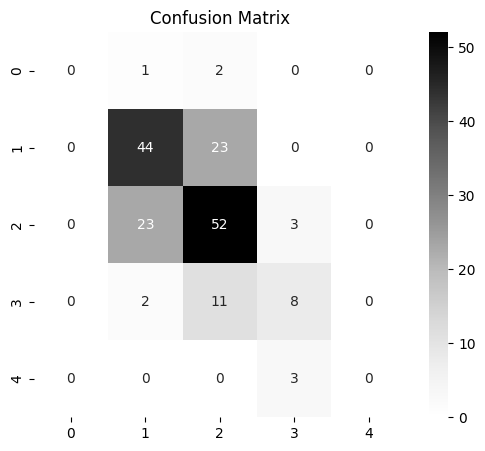

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_val, y_pred),
            annot=True, fmt='d', cmap='Greys')

plt.title("Confusion Matrix")
plt.show()

**TRAIN FINAL MODEL (MODEL DATA)**

In [ ]:
rf_model.fit(X_scaled, y)

RandomForestClassifier(n_estimators=200, random_state=42)

**PREDICT THE TESTING DATASET**

In [ ]:
test_pred = rf_model.predict(X_test_scaled)

**OUTPUT CSV**

In [ ]:
output = pd.DataFrame({
    "id": test_id,
    "quality": test_pred
})

output.to_csv("hasil_prediksi.csv", index=False)

print(output.head())

     id  quality
0   222        5
1  1514        5
2   417        5
3   754        5
4   516        5


In [ ]:
from google.colab import files
files.download("hasil_prediksi.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>